In [2]:
!nvidia-smi

Fri Jul 31 01:46:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   57C    P8             15W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# MNIST 손글씨 숫자 다중 클래스 분류
- 0~ 9 손글씨 이미지 (해상도 28 x 28)

### 학습목표
- CNN 기반 이미지 분류 모델 (이미지 특징 추출에 특화된 모델)
- train/ valid / test 데이터 분리
- 데이터 정규화 및 데이터 증강 (입력 이미지를 조금씩 변형하여 일반화 성능 향상)
- DataLoader 를 활용하여 미니배치 학습
- CrossEntropyLoss 손실함수
- AdamW 최적화함수 (Adam + Weight Decay)
- Scheduler (학습 상황에 따라 learning rate 조정)
- BatchNorm(학습 안정화, 학습 수렴 지원), Dropout(일부 램던 뉴런 비활성화, 과적합 방지), Weight Decay(특정 가중치가 너무 커지는 것을 방지, 과적합 방지)
- Gradient Clipping (기울기가 너무 커지는 문제 완화)
- EarlyStopping (일정 학습기간동안 성능 없을시 조기종료)
- 시각화
- Confusion Matrix 등 지표
- 오분류 이미지 확인

### 기본 정보
- 문제유형 : 다중 클래스 분류
- 입력 데이터 : 28x28 흑백 손글씨 이미지 
- 출력 데이터 : 숫자 클래스 0~9


In [3]:
import torch

### 1. 라이브러리 불러오기

In [34]:
import random           # 시드 고정
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

import torch
import torch.nn as nn           # 신경망 구성
import torch.optim as optim     # 최적화 함수
from torch.utils.data import DataLoader, Subset # 미니배치/ 데이터 분리

from torchvision import datasets, transforms    # 이미지 데이터셋/ 이미지 전처리 도구

from tqdm.auto import tqdm      # 진행바

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# plt.rcParams["font.family"] = "Malgun Gothic"

# plt.rcParams["axes.unicode_minus"] = False

# 코랩환경에선 한글설정 달라짐

!apt-get update -qq
!apt-get install -qq fonts-nanum

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm.fontManager.addfont(
    "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
)

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


### 2. 랜덤 시드 고정

In [5]:
SEED = 42

random.seed(SEED)                   # python random 시드 고정
np.random.seed(SEED)                # Numpy 시드 고정
torch.manual_seed(SEED)             # pytorch CPU 시드 고정
torch.cuda.manual_seed_all(SEED)    # pytorch GPU 시드 고정


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")   # GPU 사용가능 시 GPU사용(cuda), 아니면 cpu 사용
device

device(type='cuda')

### 3. MNIST 데이터 불러오기

In [6]:
# MNIST 에서 주로 전처리시에 사용하는 평균과 표준편차
MNIST_MEAN = 0.1307
MNIST_STD = 0.3081

# 학습 데이터 전처리 도구: 데이터 증강 + Tensor 변환 + 정규화
train_transform = transforms.Compose([
    transforms.RandomRotation(10),                      # 이미지를 -10 ~ 10도 범위로 랜덤 회전
    transforms.ToTensor(),                              # 이미지 내부값을 Tensor로 변환(0 ~ 1 범위로 MinMaxScaling)
    transforms.Normalize((MNIST_MEAN, ) , (MNIST_STD, ))    # 평균과 표준편차를 이용해 정규화 
])


# 검증/ 테스트 데이터 전처리 도구: Tensor 변환 + 정규화 (검증/ 테스트 시에는 증강 전처리 사용안함)
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((MNIST_MEAN, ) , (MNIST_STD, ))
])

# 학습용 MNIST 데이터 셋(증강 적용)
full_train_dataset_aug = datasets.MNIST(
    root= './data',             # 저장경로
    train= True,                # 학습/ 테스트 데이터셋 중 학습 데이터셋
    download= True,             # 데이터 없으면 다운로드
    transform= train_transform  # 전처리 적용
)

# 검증용으로 사용할 학습 데이터셋 (증강 미적용)
full_train_dataset_eval = datasets.MNIST(
    root= './data',
    train= True, 
    download= True,
    transform= eval_transform
)

# 최종 평가용 테스트 데이터셋
test_dataset = datasets.MNIST(
    root= './data',
    train= False, 
    download= True,
    transform= eval_transform
)

print(f'전체 학습 데이터 수 : {len(full_train_dataset_aug)}')
print(f'전체 검증 데이터 수 : {len(full_train_dataset_eval)}')
print(f'전체 테스트 데이터 수 : {len(test_dataset)}')

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 504kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.42MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 15.6MB/s]

전체 학습 데이터 수 : 60000
전체 검증 데이터 수 : 60000
전체 테스트 데이터 수 : 10000


In [7]:
full_train_dataset_aug[0]   # 첫 번째 학습 데이터의 데이터와 정답

(tensor([[[-0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.424

### 4. Train/Valid 데이터 분리

- train 데이터 : 모델 가중치 학습용
- valid 데이터 : 성능 확인 및 EarlyStopping 판단, Scheduler
- test 데이터 : 학습 종료 후 최종 성능 평가

In [ ]:
valid_size = 10000
train_size = len(full_train_dataset_aug) - valid_size

generater = torch.Generator().manual_seed(SEED)     # 데이터 분리시 재현성 추가를 위한 generator 객체
 # 전체 인덱스 섞어 인덱스 반환(한번 사용한 인덱스는 다시 나오지 않음)
indices = torch.randperm(len(full_train_dataset_aug), generator= generater)    

train_indices = indices[ :train_size]   # 학습용 인덱스
valid_indices = indices[valid_size: ]   # 검증용 인덱스

train_dataset = Subset(full_train_dataset_aug, train_indices)   # 데이터 분리(데이터, 인덱스). 증강 적용한 학습 데이터셋
valid_dataset = Subset(full_train_dataset_eval, valid_indices)  # 증강 없는 검증 데이터셋

print(f'학습 데이터 수 : {len(train_dataset)}, 검증 수 : {len(valid_dataset)}, 테스트 데이터 수 : {len(test_dataset)}')

학습 데이터 수 : 50000, 검증 수 : 10000, 테스트 데이터 수 : 10000


### 5. 클래스 분포 확인

In [9]:
full_train_dataset_eval.targets[train_indices].numpy()

array([6, 7, 6, ..., 4, 4, 0])

In [10]:
class_name = [str(i) for i in range(10)]

train_labels = full_train_dataset_eval.targets[train_indices].numpy()
valid_labels = full_train_dataset_eval.targets[train_indices].numpy()
test_labels = test_dataset.targets.numpy()

label_df = pd.DataFrame({
    'train' : pd.Series(train_labels).value_counts().sort_index(),
    'valid' : pd.Series(valid_labels).value_counts().sort_index(),
    'test' : pd.Series(test_labels).value_counts().sort_index(),
})

In [11]:
label_df

,train,valid,test
0,4923,4923,980
1,5613,5613,1135
2,4958,4958,1032
3,5093,5093,1010
4,4863,4863,982
5,4546,4546,892
6,4933,4933,958
7,5204,5204,1028
8,4882,4882,974
9,4985,4985,1009


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

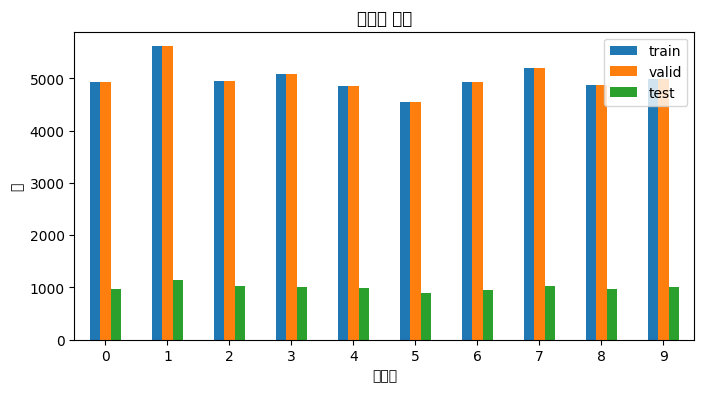

In [12]:
label_df.plot(kind = 'bar', figsize=(8, 4))
plt.title('클래스 분포')
plt.xlabel('클래스')
plt.ylabel('수')
plt.xticks(rotation= 0)
plt.show()

### 6. DataLoader 생성하여 미니배치 학습

In [13]:
BATCH_SIZE = 128            # 이미지 128장 씩 사용

train_loader= DataLoader(
    train_dataset,          
    batch_size= BATCH_SIZE, 
    shuffle= True,          # epoch 마다 섞음
    num_workers= 0          # 병렬처리 코어 (0은 메인코어)
)

valid_loader= DataLoader(
    valid_dataset,
    batch_size= BATCH_SIZE,
    shuffle= False,
    num_workers= 0
)

test_loader= DataLoader(
    test_dataset,
    batch_size= BATCH_SIZE,
    shuffle= False,
    num_workers= 0
)

# 미니배치 하나를 꺼내서 형태 확인
images, labels = next(iter(train_loader))       
print(f'images.shape : {images.shape}, labels.shape : {labels.shape}')  # (batch, channel, height, width)

images.shape : torch.Size([128, 1, 28, 28]), labels.shape : torch.Size([128])


torch.Size([배치 사이즈, 컬러(0, 1 이면 흑백), width, height])

### 7. 이미지 데이터 확인

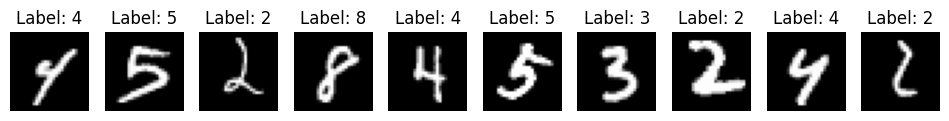

In [14]:
# 역정규화 함수 : 시각화해서 표현하기 위해 원래 범위에 가깝게 되돌리는 함수
def denormalize(image_tensor):
    return image_tensor * MNIST_STD + MNIST_MEAN

def show_images(dataset, n= 10):
    plt.figure(figsize= (12, 2))
    
    for i in range(n):
        image, label = dataset[i]
        # 흑백이미지는 차원이 1일 경우 삭제
        # 컬러 이미지는 삭제하지 않음, 컬러 이미지는 : imshow[높이, 너비 , 채널] 순으로 맞춰사용
        image = denormalize(image).squeeze(0)   
        
        plt.subplot(1, n, i+1)
        plt.imshow(image, cmap='gray')
        plt.title(f'Label: {label}')
        plt.axis('off')
        
    plt.show()
    
show_images(valid_dataset, 10)

###

### 8. CNN 기반 이미지 분류모델

In [15]:
# MNIST 손글씨 이미지를 0~9중 하나로 분류하는 모델
class MNISTCNN(nn.Module):

    def __init__(self, dropout_rate= 0.25):
        super().__init__()
        
        # 이미지에서 특징을 추출하는 부분
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size= 3, padding= 1),   # 흑백 이미지 1채널 -> 특징맵 16개 생성
            nn.BatchNorm2d(16),     # 16개 채널값 정규화
            nn.SiLU(),              # 비선형 추가
            nn.MaxPool2d(kernel_size= 2),   # 이미지 크기를 전반으로 축소(28x28 -> 14x14)
            nn.Dropout2d(dropout_rate),     # 랜덤으로 특징맵 비활성화 (과적합 완화)

            
            nn.Conv2d(16, 32, kernel_size= 3, padding= 1),  # 특징맵 16 -> 32개 확장 (다양한 특징 추출)
            nn.BatchNorm2d(32),
            nn.SiLU(),
            nn.MaxPool2d(kernel_size= 2),       # 이미지 크기를 절반으로 축소 (14x14 -> 7x7)
            nn.Dropout2d(dropout_rate)       
        )
        
        # 추출된 특징을 바탕으로 최종 클래스 분류하는 분류기
        self.classifier = nn.Sequential(
            nn.Flatten(),                   # 3차원의 특징맵을 1차원 벡터로 변환 : 32 * 7 * 7 -> 1568
            nn.Linear(32* 7 * 7, 128),      # 1568 개의 특징 벡터를 128개의 은닉 노드로 변환
            nn.BatchNorm1d(128),            # 출력 정규화
            nn.SiLU(),                      # 비선형 추가
            nn.Dropout(0.4),                # 일부 뉴련 비활성화 (과적합 완화)
            nn.Linear(128, 10)              # 출력 : 숫자 0 ~ 9 의 10개 클래스 점수
        )
        
    def forward(self, x):   
        x= self.features(x)     # 특징 추출
        x= self.classifier(x)   # 클래스별 점수 계산
        return x                # softmax 함수 적용 전 logits 
    
model = MNISTCNN().to(device)
model

MNISTCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): SiLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.25, inplace=False)
    (5): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): SiLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout2d(p=0.25, inplace=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=128, bias=True)
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): SiLU()
    (4): Dropout(p=0.4, inplace=False)
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)

### 9. 손실함수, 최적화 함수, Scheduler 설정
- CrossEntropyLoss 손실함수 : 모델 출력값을 내부적으로 확률로 처리하여, 모델의 출력부분에 SoftMax를 따로 붙이지 않아도 된다.


In [16]:
# 다중 클래스 분류용 손실함수(5% 는 정답 미확신)
criterion = nn.CrossEntropyLoss(label_smoothing= 0.05)

optimizer = optim.AdamW(
    model.parameters(),     # 학습할 모델 파라미터
    lr = 0.001,             # 학습률
    weight_decay= 1e-4      # L2 규제 수치(과적합 완화)
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,      
    mode = 'min',       # valid_loss 기준이라 감소하는 방향
    factor= 0.5,        # learning rate 감소율
    patience= 2         # 2 epoch 동안 개선 없으면 조정
)

### 10. EarlyStopping 클래스 정의
- 일정 epoch 동안 개선이 없으면 학습 조기종료

In [17]:
class EarlyStopping:
    
    def __init__(self, patience= 4, min_delta= 0.0):
        self.patience = patience                # 개선을 기다릴 epoch
        self.min_delta = min_delta              # 개선으로 인정할 최소 변화량
        self.best_loss = float('inf')           # 최소 valid loss
        self.counter = 0                        # 개선이 없었던 epoch
        self.best_state = None                  # 최고 성능 모델 가중치
    
    def __call__(self, valid_loss, model):          
        if valid_loss < self.best_loss - self.min_delta:
            self.best_loss = valid_loss
            self.counter = 0
            self.best_state = {
               key : value.detach().cpu().clone() for key, value in model.state_dict().items()
            }
            return False
        
        self.counter += 1
        return self.counter >= self.patience
    
    # 가장 성능이 좋은 모델의 가중치를 모델에 복원
    def restore_best_weights(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)
        

### 11. 학습함수와 평가함수 정의

In [18]:
# 모델을 1 epoch 학습하는 함수
def train_one_epoch(model, dataloader, criterion, optimizer, device, max_norm = 1.0):
    model.train()
    
    total_loss = 0.0        # 전체 손실(평균 계산)
    total_correct = 0       # 맞춘 갯수(정확도 계산)
    total_count = 0         # 총 갯수(평균, 정확도 계산)
    
    for images, labels in tqdm(dataloader, desc='Train', leave = False):
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()               # 기울기 초기화
        
        outputs = model(images)             # 예측 logits 반환
        loss = criterion(outputs, labels)   # 손실 계산(내부에서 softmax로 확률 변환)
        
        loss.backward()     # 기울기 계산
        # Gradient Clipping : 특정 기울기 폭주 방지 (규제) -> 과적합 방지
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm= max_norm)
        optimizer.step()     # 가중치 업데이트
        
        batch_size = images.size(0)
        total_loss += loss.item() * batch_size      # 배치 전체 loss 누적
        # 클래스별 점수 중 가장 큰 값의 인덱스가 정답이랑 같은 것(예측성공)의 갯수
        total_correct += (outputs.argmax(dim= 1) == labels).sum().item()
        total_count += batch_size
        
    avg_loss = total_loss / total_count     # epoch 전체 평균 손실
    avg_acc = total_correct / total_count   # epoch 전체 정확도
    return avg_loss, avg_acc

In [19]:
# 평가하는 함수

def evaluate(model, dataloader, criterion, device):
    model.eval()            # 평가모드 (모델 내부 과적합 완화 기법 사용안함)

    total_loss = 0.0        # 전체 손실(평균 계산)
    total_correct = 0       # 맞춘 갯수(정확도 계산)
    total_count = 0         # 총 갯수(평균, 정확도 계산)
    
    

    with torch.no_grad():    # 평가중에 기울기 계산 비활성화
        for images, labels in tqdm(dataloader, desc='Evaluate', leave = False): # 진행바 남기지 않음
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)             # 예측 logits 반환
            loss = criterion(outputs, labels)   # 손실 계산(내부에서 softmax로 확률 변환)

            batch_size = images.size(0)
            total_loss += loss.item() * batch_size      # 배치 전체 loss 누적
            
            # 클래스별 점수 중 가장 큰 값의 인덱스가 정답이랑 같은 것(예측성공)의 갯수를 python 숫자형태로 
            total_correct += (outputs.argmax(dim= 1) == labels).sum().item()
            total_count += batch_size
        
    avg_loss = total_loss / total_count     # epoch 전체 평균 손실
    avg_acc = total_correct / total_count   # epoch 전체 정확도
    return avg_loss, avg_acc

### 12. 모델 학습

In [20]:
EPOCHS = 10

early_stopping = EarlyStopping(patience= 4, min_delta= 0.0001)
history= []

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    valid_loss, valid_acc = evaluate(model, valid_loader, criterion, device)
    
    scheduler.step(valid_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    history.append({
        'epoch' : epoch +1,
        'train_loss' : train_loss,
        'train_acc' : train_acc,
        'valid_loss' : valid_loss,
        'valid_acc' : valid_acc,
        'lr' : current_lr
    })
    
    print(
        f'Epoch: {epoch + 1} |'
        f'Train loss : {train_loss:.4} | Train ACC : {train_acc:.4f}|'
        f'Valid loss : {valid_loss:.4} | Valid ACC : {valid_acc:.4f}|'
        f'Learning Rate : {current_lr:.6f}'
        
    )
    
    if early_stopping(valid_loss, model):
        print("검증 손실 개선이 이루어지지 않아 EarlyStopping 작동")
        break

early_stopping.restore_best_weights(model)

Train:   0%|          | 0/391 [00:00<?, ?it/s]

Evaluate:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch: 1 |Train loss : 0.5724 | Train ACC : 0.9228|Valid loss : 0.387 | Valid ACC : 0.9800|Learning Rate : 0.001000


Train:   0%|          | 0/391 [00:00<?, ?it/s]

Evaluate:   0%|          | 0/79 [00:00<?, ?it/s]

...

Evaluate:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch: 9 |Train loss : 0.3832 | Train ACC : 0.9828|Valid loss : 0.3475 | Valid ACC : 0.9890|Learning Rate : 0.001000


Train:   0%|          | 0/391 [00:00<?, ?it/s]

Evaluate:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch: 10 |Train loss : 0.3825 | Train ACC : 0.9818|Valid loss : 0.3455 | Valid ACC : 0.9902|Learning Rate : 0.001000


### 13. 학습 과정 시각화

In [21]:
history_df = pd.DataFrame(history)
history_df


,epoch,train_loss,train_acc,valid_loss,valid_acc,lr
0,1,0.572424,0.92284,0.387010,0.9800,0.001
1,2,0.441826,0.96356,0.373065,0.9833,0.001
2,3,0.422240,0.97038,0.369351,0.9847,0.001
3,4,0.408850,0.97518,0.364436,0.9865,0.001
4,5,0.399461,0.97790,0.356968,0.9878,0.001
5,6,0.394852,0.97934,0.352460,0.9884,0.001
6,7,0.390496,0.98024,0.352386,0.9881,0.001
7,8,0.386236,0.98100,0.350156,0.9884,0.001
8,9,0.383247,0.98276,0.347487,0.9890,0.001
9,10,0.382494,0.98182,0.345532,0.9902,0.001


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51613 (\N{HANGUL SYLLABLE JEUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49552 (\N{HANGUL SYLLABLE SON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/

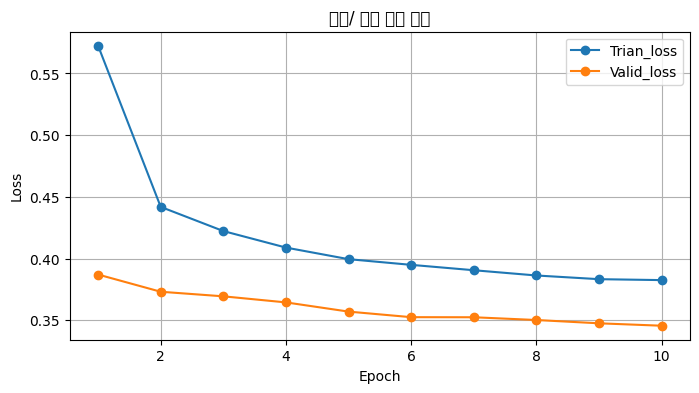

In [22]:
# Train and Validation Loss

plt.figure(figsize=(8, 4))
plt.plot(history_df['epoch'], history_df['train_loss'], marker='o', label='Trian_loss')
plt.plot(history_df['epoch'], history_df['valid_loss'], marker='o', label='Valid_loss')
plt.title('학습/ 검증 손실 곡선')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


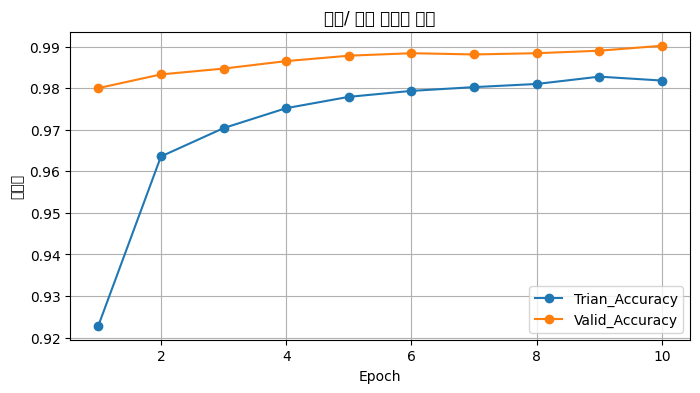

In [23]:
# Train and Validation 정확도 곡선

plt.figure(figsize=(8, 4))
plt.plot(history_df['epoch'], history_df['train_acc'], marker='o', label='Trian_Accuracy')
plt.plot(history_df['epoch'], history_df['valid_acc'], marker='o', label='Valid_Accuracy')
plt.title('학습/ 검증 정확도 곡선')
plt.xlabel('Epoch')
plt.ylabel('정확도')
plt.legend()
plt.grid(True)
plt.show()

### 14. Test 데이터로 최종평가

In [24]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print(f'Test Loss : {test_loss}, Test Accuracy : {test_acc}')

Evaluate:   0%|          | 0/79 [00:00<?, ?it/s]

Test Loss : 0.34110622758865355, Test Accuracy : 0.9906


### 15. 예측 결과 수집 & 시각화

In [25]:
def get_predictions(model, dataloader, device):
    model.eval()            # 평가모드 (모델 내부 과적합 완화 기법 사용안함)

    y_true = []     # 실제정답
    y_pred = []     # 예측 클래스
    y_prob = []     # 예측확률

    with torch.no_grad():    # 평가중에 기울기 계산 비활성화
        for images, labels in tqdm(dataloader, desc=' Get Predictions', leave= False):
            images = images.to(device)
            
            outputs = model(images)             # 예측 logits 반환
            prediction = outputs.argmax(dim = 1)    # 가장 높은 점수 클래스를 예측값으로 선택
            probabilities = torch.softmax(outputs, dim = 1)     # logits 을 클래스별 확률로 변환
        
            y_true.append(labels.numpy())                   # 실제 정답 numpy 배열 형태로 저장
            y_pred.append(prediction.cpu().numpy())         # 예측 클래스도 CPU 이동 후 numpy 형태 저장
            y_prob.append(probabilities.cpu().numpy())      # 예측 확률도 CPU 이동 후 numpy 형태 저장
            
    return np.concatenate(y_true),np.concatenate(y_pred),np.concatenate(y_prob) # 배치별 값을 하나의 배열 형태로 합침

y_true, y_pred, y_prob = get_predictions(model, test_loader, device)

print(y_true[:20])
print(y_pred[:20])

 Get Predictions:   0%|          | 0/79 [00:00<?, ?it/s]

[7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]
[7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]


In [26]:
print(f'Test Accuracy : {accuracy_score(y_true, y_pred)}')
print(classification_report(y_true, y_pred, target_names= class_name))

Test Accuracy : 0.9906
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.99      0.99      1032
           3       1.00      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.98      0.99      0.99      1028
           8       1.00      0.99      0.99       974
           9       0.99      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



### 16. Confusion Matrix

<function matplotlib.pyplot.show(close=None, block=None)>

/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 54844 (\N{HANGUL SYLLABLE HON}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 54665 (\N{HANGUL SYLLABLE HAENG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 47148 (\N{HANGUL SYLLABLE RYEOL}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54844 (\N{HANGUL SYLLABLE HON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 4

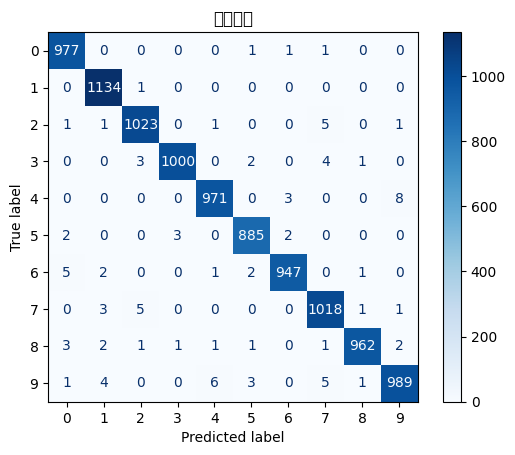

In [27]:
cm = confusion_matrix(y_true, y_pred)   # 혼동행렬 계산


disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels = class_name
)

disp.plot(cmap = "Blues", values_format = 'd')
plt.title('혼동행렬')
plt.show

### 17. 예측결과 이미지 확인

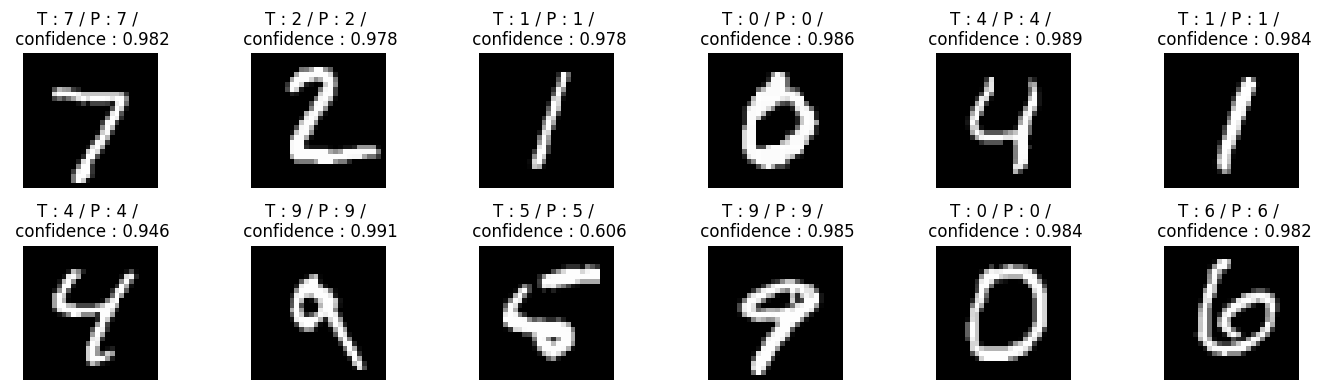

In [28]:
def show_predictions(dataset, y_pred, y_prob,  n=12):
    plt.figure(figsize=(14, 4))
    
    for i in range(n):
        image, label = dataset[i]
        image_for_plot = denormalize(image).squeeze(0)
        
        pred_label = y_pred[i]
        confidence = y_prob[i, pred_label]
        
        plt.subplot(2, 6, i+1)
        plt.imshow(image_for_plot, cmap = 'gray')
        plt.title(f'T : {label} / P : {pred_label} / \n confidence : {confidence:.3f}')
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

show_predictions(test_dataset, y_pred, y_prob)

### 18. 오분류 이미지 확인

In [29]:
np.where(y_true != y_pred)

(array([ 149,  247,  259,  321,  582,  659,  740,  924,  938,  947, 1014,
        1033, 1226, 1232, 1242, 1247, 1260, 1319, 1393, 1500, 1530, 1549,
        1621, 1681, 1709, 1717, 1754, 1878, 1901, 2040, 2109, 2118, 2129,
        2130, 2135, 2189, 2293, 2387, 2447, 2454, 2462, 2488, 2597, 2654,
        2771, 2896, 2927, 2939, 3030, 3060, 3073, 3422, 3475, 3503, 3520,
        3558, 3726, 3808, 3850, 3941, 4007, 4163, 4176, 4500, 4571, 4639,
        4740, 4761, 4823, 4860, 4956, 5067, 5734, 5937, 5955, 6505, 6569,
        6571, 6576, 6597, 6625, 6651, 8408, 8520, 9009, 9015, 9019, 9642,
        9664, 9692, 9729, 9770, 9839, 9888]),)

In [30]:
wrong_indices = np.where(y_true != y_pred)[0]
print(f'못 맞춘 갯수 : {len(wrong_indices)}')

못 맞춘 갯수 : 94


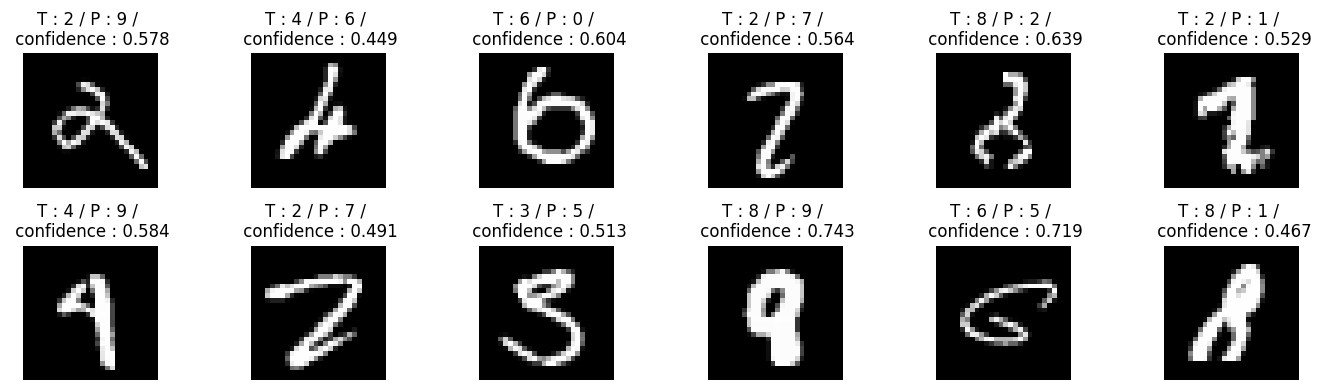

In [31]:
# 오분류 이미지 출력함수
def show_mispredictions(dataset,wrong_indices, y_pred, y_prob,  n=12):
    
    if len(wrong_indices) ==0:
        print('오분류 이미지 없음')
        return
    
    n = min(n, len(wrong_indices))
    
    
    
    plt.figure(figsize=(14, 4))
    
    for plot_idx in range(n):
        data_idx = wrong_indices[plot_idx]
        
        image, label = dataset[data_idx]
        image_for_plot = denormalize(image).squeeze(0)      # 역정규화 및 채널차원 제거
        
        pred_label = y_pred[data_idx]
        confidence = y_prob[data_idx, pred_label]
        
        plt.subplot(2, 6, plot_idx +1)
        plt.imshow(image_for_plot, cmap = 'gray')
        plt.title(f'T : {label} / P : {pred_label} / \n confidence : {confidence:.3f}')
        plt.axis('off')     # 축 제거
        
    plt.tight_layout()
    plt.show()

show_mispredictions(test_dataset, wrong_indices, y_pred, y_prob)

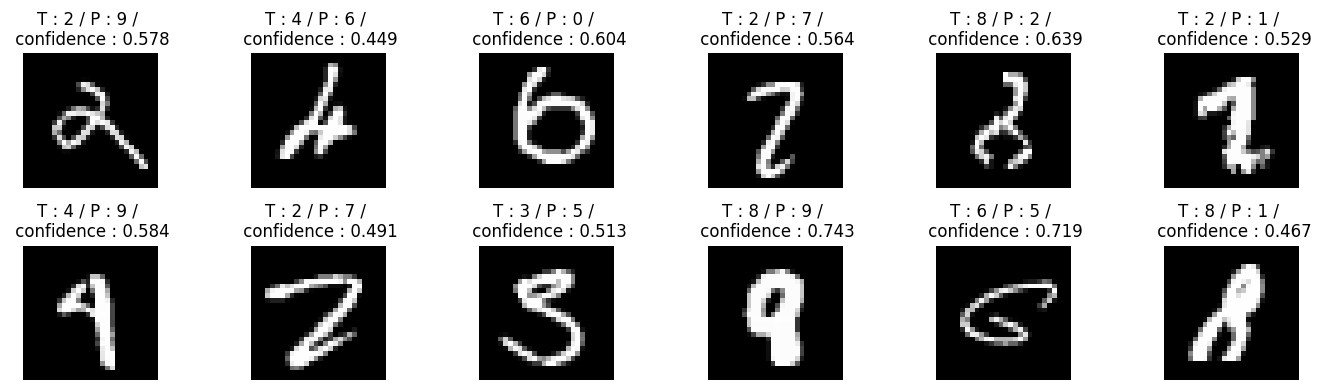

In [32]:
# 오분류 이미지 출력함수
def show_mispredictions_active(dataset,wrong_indices, y_pred, y_prob,  n=12):
    
    # 오분류 이미지 없을 시 함수종료
    if len(wrong_indices) ==0:
        print('오분류 이미지 없음')
        return
    
    n = min(n, len(wrong_indices))      # 요청 갯수, 못맞춘 갯수 중 최소값
    
    cols = min(6, n)                    # 한 줄에 최대 6개 까지만 출력
    rows = int(np.ceil(n / cols))       # 필요한 행 개수
    
    fig, axes = plt.subplot(
        rows, 
        cols, 
        figsize = (cols * 2.3, rows * 2.5)
    )
    
    axes = np.array(axes).reshape(-1)       # 1차원 배열로 변환(반복문 안에서 사용하기 위해)
    
    plt.figure(figsize=(14, 4))
    
    for plot_idx in range(n):   
        data_idx = wrong_indices[plot_idx]      # 오분류한 데이터의 인덱스
        
        image, label = dataset[data_idx]
        image_for_plot = denormalize(image).squeeze(0).cpu().numpy()      # 역정규화 및 채널차원 제거(시각화용 numpy 변환)
        
        pred_label = y_pred[data_idx]
        confidence = y_prob[data_idx, pred_label]
        
        axes[plot_idx].imshow(image_for_plot, cmap='gray')
        axes[plot_idx].set_title(f'T : {label} / P : {pred_label} / \n confidence : {confidence:.3f}')
        axes[plot_idx].axis('off')
        
    for empty_idx in range(n, len(axes)):
        axes[empty_idx].axis('off')
        
    plt.tight_layout()
    plt.show()

show_mispredictions(test_dataset, wrong_indices, y_pred, y_prob)

### 19. 단일 이미지 예측 함수

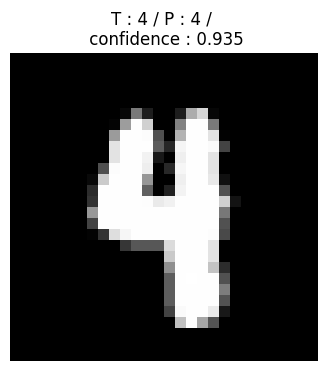

(4, 0.9345605373382568)

In [33]:
def predict_one_image(model, dataset, index, device):
    model.eval()            # 평가모드 (모델 내부 과적합 완화 기법 사용안함)

    image, true_label = dataset[index]
    input_image = image.unsqueeze(0).to(device)         # Bathc 차원 추가해서 X 데이터처럼 만듬 (C, H, W) -> (B, C, H, W)

    with torch.no_grad():    # 평가중에 기울기 계산 비활성화
            
        output = model(input_image)                          # 예측 logits 반환
        probability = torch.softmax(output, dim = 1)         # 클래스별 확률
        pred_label = probability.argmax(dim = 1).item()      # 예츨 클래스
        confidence = probability[0, pred_label].item()       # 예측 확률 추출
        

    plt.figure(figsize=(8, 4))
    # 역정규화 / 채널 차원 제거해서 흑백이미지로 출력
    plt.imshow(denormalize(image).squeeze(0), cmap = 'gray')
    plt.title(f'T : {true_label} / P : {pred_label} / \n confidence : {confidence:.3f}')
    plt.axis('off')
    
    plt.show()

        
        
        
        
    return pred_label, confidence


predict_one_image(model, test_dataset,index= 250, device=device)

고도화 기법
- Dropout 수치 변경/ 제거
- Weight Decay 수치 변경 /제거
- Data Agumentation 여러 기법 도입/ 제거
- Batch Normalization 수치 변경/ 제거
- 모델 하이퍼파라미터 최적화